![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

In [3]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [4]:
from upvfab_design_tools import MMI_EME, DC_EME

In [5]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## LO.1. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


Text(0, 0.5, 'K')

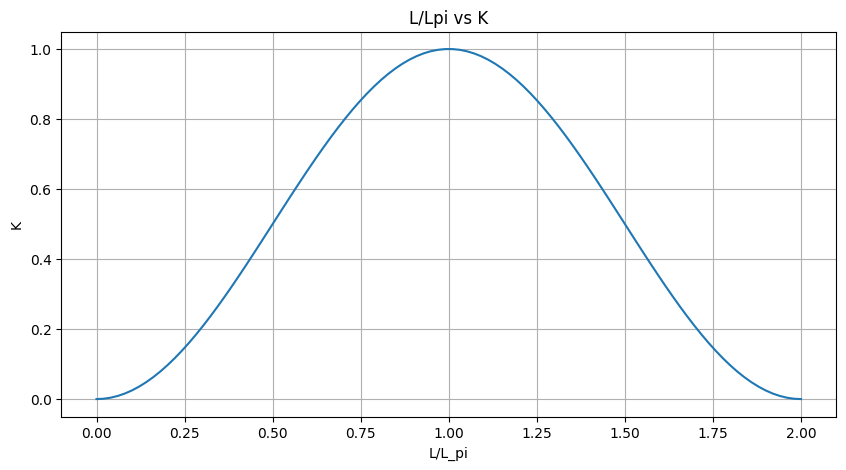

In [4]:
wg_gap = 0.6 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()

L = np.linspace(0,2*L_pi,100)
K = np.zeros(100)
for i in range(100):
    K[i] = (np.sin(1/2*np.pi*(L[i]/L_pi)))**2

plt.figure(figsize=(10, 5))
plt.title(f"L/Lpi vs K")
plt.grid()
plt.plot(L/L_pi, K)
plt.xlabel("L/L_pi")
plt.ylabel("K")


## LO.2. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [5]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 0.6 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  94.02751777693351  µm


/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


In [6]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 0.6 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2


m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  94.02751777693605  µm


/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0138
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9687
Total OUT power: 0.9582
Excess loss [dB] =  0.1855
------------------------
Power over OUTs:  ['0.4790', '0.4792']
Ratio over OUTs ['0.4999', '0.5001']


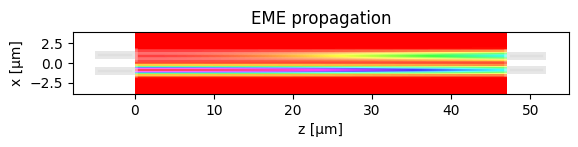

In [7]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*np.abs(L_pi) # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation

m.propagation()

/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  128.0656599436639  µm


/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1281 [00:00<?, ?it/s]

------- Pameters -------
MMI length 64.0328
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9842
Total OUT power: 0.9738
Excess loss [dB] =  0.1153
------------------------
Power over OUTs:  ['0.4870', '0.4868']
Ratio over OUTs ['0.5001', '0.4999']


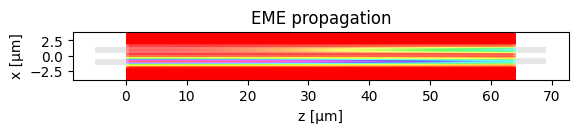

In [8]:
wg_gap = 0.7 
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2


m = DC_EME() 
m.MMI_num_modes = 12 
                    
m.DC_wg_gap = wg_gap 
m.DC_wg_width = wg_width 
m.DC_N_waveguides = wg_N

m.find_all_modes()

L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*np.abs(L_pi)
                
# 4) Run propagation - get power transfer and plot propagation

m.propagation()

/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  173.96402979405414  µm


/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1740 [00:00<?, ?it/s]

------- Pameters -------
MMI length 86.9820
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9881
Total OUT power: 0.9777
Excess loss [dB] =  0.0981
------------------------
Power over OUTs:  ['0.4887', '0.4890']
Ratio over OUTs ['0.4998', '0.5002']


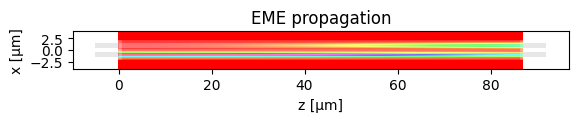

In [9]:
wg_gap = 0.8 
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2


m = DC_EME() 
m.MMI_num_modes = 12 
                    
m.DC_wg_gap = wg_gap 
m.DC_wg_width = wg_width 
m.DC_N_waveguides = wg_N

m.find_all_modes()

L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*np.abs(L_pi)
                
# 4) Run propagation - get power transfer and plot propagation

m.propagation()

/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  235.77449267369866  µm


/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2358 [00:00<?, ?it/s]

------- Pameters -------
MMI length 117.8872
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9832
Total OUT power: 0.9729
Excess loss [dB] =  0.1194
------------------------
Power over OUTs:  ['0.4864', '0.4865']
Ratio over OUTs ['0.5000', '0.5000']


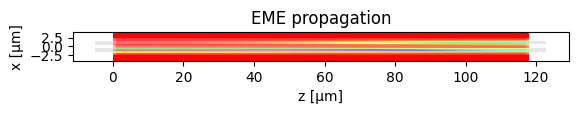

In [10]:
wg_gap = 0.9
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2


m = DC_EME() 
m.MMI_num_modes = 12 
                    
m.DC_wg_gap = wg_gap 
m.DC_wg_width = wg_width 
m.DC_N_waveguides = wg_N

m.find_all_modes()

L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*np.abs(L_pi)
                
# 4) Run propagation - get power transfer and plot propagation

m.propagation()

/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  -318.88426739146814  µm


/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/3189 [00:00<?, ?it/s]

------- Pameters -------
MMI length 159.4421
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9662
Total OUT power: 0.9559
Excess loss [dB] =  0.1959
------------------------
Power over OUTs:  ['0.4777', '0.4782']
Ratio over OUTs ['0.4997', '0.5003']


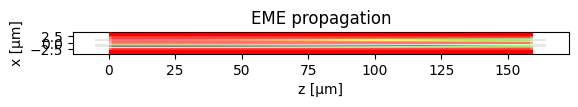

In [11]:
wg_gap = 1 
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2


m = DC_EME() 
m.MMI_num_modes = 12 
                    
m.DC_wg_gap = wg_gap 
m.DC_wg_width = wg_width 
m.DC_N_waveguides = wg_N

m.find_all_modes()

L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*np.abs(L_pi)
                
# 4) Run propagation - get power transfer and plot propagation

m.propagation()

/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  430.5475743532674  µm


/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4305 [00:00<?, ?it/s]

------- Pameters -------
MMI length 215.2738
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9360
Total OUT power: 0.9258
Excess loss [dB] =  0.3347
------------------------
Power over OUTs:  ['0.4629', '0.4630']
Ratio over OUTs ['0.4999', '0.5001']


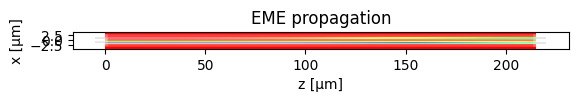

In [12]:
wg_gap = 1.1
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2


m = DC_EME() 
m.MMI_num_modes = 12 
                    
m.DC_wg_gap = wg_gap 
m.DC_wg_width = wg_width 
m.DC_N_waveguides = wg_N

m.find_all_modes()

L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*np.abs(L_pi)
                
# 4) Run propagation - get power transfer and plot propagation

m.propagation()

/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  -580.4291411429296  µm


/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5804 [00:00<?, ?it/s]

------- Pameters -------
MMI length 290.2146
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8917
Total OUT power: 0.8819
Excess loss [dB] =  0.5458
------------------------
Power over OUTs:  ['0.4408', '0.4411']
Ratio over OUTs ['0.4998', '0.5002']


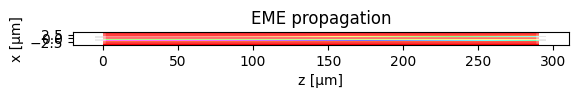

In [13]:
wg_gap = 1.2
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2


m = DC_EME() 
m.MMI_num_modes = 12 
                    
m.DC_wg_gap = wg_gap 
m.DC_wg_width = wg_width 
m.DC_N_waveguides = wg_N

m.find_all_modes()

L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*np.abs(L_pi)
                
# 4) Run propagation - get power transfer and plot propagation

m.propagation()

/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  781.3901748461363  µm


/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/7814 [00:00<?, ?it/s]

------- Pameters -------
MMI length 390.6951
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8473
Total OUT power: 0.8378
Excess loss [dB] =  0.7684
------------------------
Power over OUTs:  ['0.4188', '0.4191']
Ratio over OUTs ['0.4998', '0.5002']


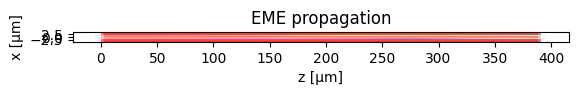

In [14]:
wg_gap = 1.3
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2


m = DC_EME() 
m.MMI_num_modes = 12 
                    
m.DC_wg_gap = wg_gap 
m.DC_wg_width = wg_width 
m.DC_N_waveguides = wg_N

m.find_all_modes()

L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*np.abs(L_pi)
                
# 4) Run propagation - get power transfer and plot propagation

m.propagation()

/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  -1050.47851262183  µm


/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/10505 [00:00<?, ?it/s]

------- Pameters -------
MMI length 525.2393
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.7871
Total OUT power: 0.7782
Excess loss [dB] =  1.0890
------------------------
Power over OUTs:  ['0.3890', '0.3893']
Ratio over OUTs ['0.4998', '0.5002']


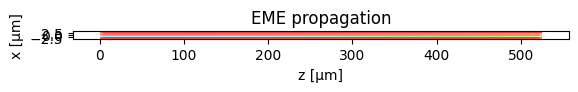

In [15]:
wg_gap = 1.4
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2


m = DC_EME() 
m.MMI_num_modes = 12 
                    
m.DC_wg_gap = wg_gap 
m.DC_wg_width = wg_width 
m.DC_N_waveguides = wg_N

m.find_all_modes()

L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*np.abs(L_pi)
                
# 4) Run propagation - get power transfer and plot propagation

m.propagation()

/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  -1410.6605285151893  µm


/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/14107 [00:00<?, ?it/s]

------- Pameters -------
MMI length 705.3303
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.7299
Total OUT power: 0.7216
Excess loss [dB] =  1.4167
------------------------
Power over OUTs:  ['0.3608', '0.3609']
Ratio over OUTs ['0.4999', '0.5001']


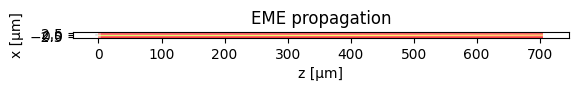

In [16]:
wg_gap = 1.5
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2


m = DC_EME() 
m.MMI_num_modes = 12 
                    
m.DC_wg_gap = wg_gap 
m.DC_wg_width = wg_width 
m.DC_N_waveguides = wg_N

m.find_all_modes()

L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*np.abs(L_pi)
                
# 4) Run propagation - get power transfer and plot propagation

m.propagation()

/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  -1892.467044058141  µm


/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/18925 [00:00<?, ?it/s]

------- Pameters -------
MMI length 946.2335
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.6724
Total OUT power: 0.6648
Excess loss [dB] =  1.7729
------------------------
Power over OUTs:  ['0.3327', '0.3321']
Ratio over OUTs ['0.5004', '0.4996']


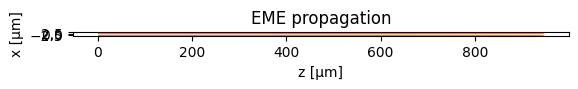

In [17]:
wg_gap = 1.6
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2


m = DC_EME() 
m.MMI_num_modes = 12 
                    
m.DC_wg_gap = wg_gap 
m.DC_wg_width = wg_width 
m.DC_N_waveguides = wg_N

m.find_all_modes()

L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*np.abs(L_pi)
                
# 4) Run propagation - get power transfer and plot propagation

m.propagation()

/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  -1892.4670440519844  µm


/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/18925 [00:00<?, ?it/s]

------- Pameters -------
MMI length 946.2335
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.6724
Total OUT power: 0.6648
Excess loss [dB] =  1.7729
------------------------
Power over OUTs:  ['0.3327', '0.3321']
Ratio over OUTs ['0.5004', '0.4996']


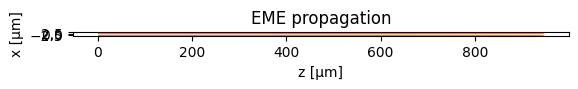

In [18]:
wg_gap = 1.6
wg_width = 1.2 

d = wg_width + wg_gap
wg_N = 2


m = DC_EME() 
m.MMI_num_modes = 12 
                    
m.DC_wg_gap = wg_gap 
m.DC_wg_width = wg_width 
m.DC_N_waveguides = wg_N

m.find_all_modes()

L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*np.abs(L_pi)
                
# 4) Run propagation - get power transfer and plot propagation

m.propagation()

Entramos con toda la potencia por el puerto 2 y sale toda la potencia por el puerto 1 (porque hemos puesto l_Pi)

## LO.3. Parallel uncoupled waveguides

In [11]:
# HINT. Calculate manually the L_pi you may need to achieve K=0.1
# Then you can sweep the gap and calculate the L_pi until reaching 
# the desired value. 

# We first calculate the Lpi needed to achieve K = 0.01 with a length typical of a chip L = 10mm

# Datos
K = 0.1
L = 10e-3  # 10 mm en metros

# Cálculo
L_pi = (np.pi * L) / (2 * np.arcsin(np.sqrt(K)))

# Resultado en mm
L_pi_TE_mm = L_pi * 1e3

print(f"L_pi TE requerido = {L_pi_TE_mm:.4f} mm")

L_pi TE requerido = 48.8203 mm


In [8]:
wg_gap = np.linspace(0.6,2,30) # Student. Gap between waveguides
wg_width = 1 # Student. Core waveguides width
L_pi = np.zeros(30)
K = np.zeros(30)
L = 10*1000 #um

for i in range(30):

    d = wg_width + wg_gap[i]
    wg_N = 2

    m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
    m.MMI_num_modes = 1 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
    m.DC_wg_gap = wg_gap[i] # Gap between waveguides
    m.DC_wg_width = wg_width # Width of the waveguides core
    m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
    m.find_all_modes()

# 2) Get the L_pi 
    L_pi[i] = m.get_L_pi()

    K[i] = (np.sin(1/2*np.pi*(L/L_pi[i])))**2

plt.figure(figsize=(10, 5))
plt.title(f"Gap vs K")
plt.grid()
plt.plot(wg_gap, K)
plt.xlabel("Gap")
plt.ylabel("K")


/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


IndexError: list index out of range

In [12]:
wg_width = 1
L = 10*1000  # um

gaps = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5]

L_pi = []
K = []

for gap in gaps:

    m = DC_EME()
    m.MMI_num_modes = 12
    m.DC_wg_gap = gap
    m.DC_wg_width = wg_width
    m.DC_N_waveguides = 2

    m.find_all_modes()

    Lpi = m.get_L_pi()
    L_pi.append(Lpi)

    K_val = np.sin(0.5*np.pi*(L/Lpi))**2
    K.append(K_val)

/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis

Text(0.5, 1.0, 'Gap vs K')

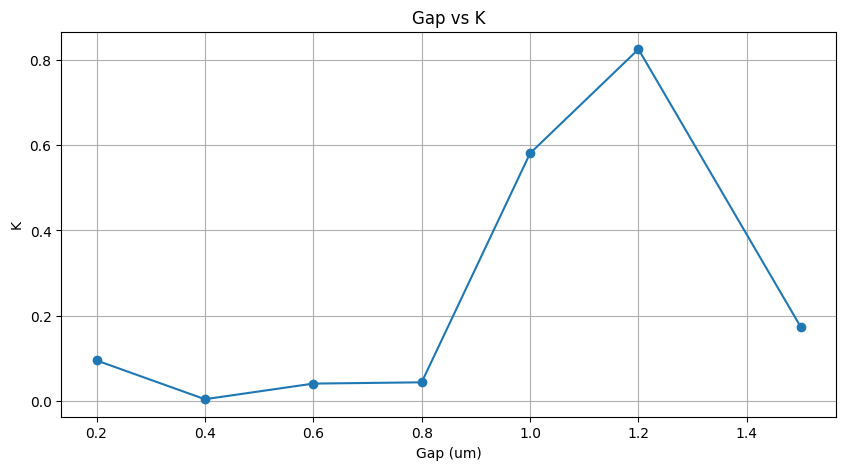

In [13]:
plt.figure(figsize=(10,5))
plt.plot(gaps, K,'o-')
plt.grid()
plt.xlabel("Gap (um)")
plt.ylabel("K")
plt.title("Gap vs K")

## LO.4. 2x2 Multimode Interference Coupler

### LO.4.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [20]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03590455330033  µm


/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/670 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -1.0000
IO wg width 1.0000
IO wg width increment 0.1000
------------------------
Total power IN coupled 0.9644
Total OUT power: 0.9004
Excess loss [dB] =  0.4557
------------------------
Power over OUTs:  ['0.4520', '0.4484']
Ratio over OUTs ['0.5020', '0.4980']


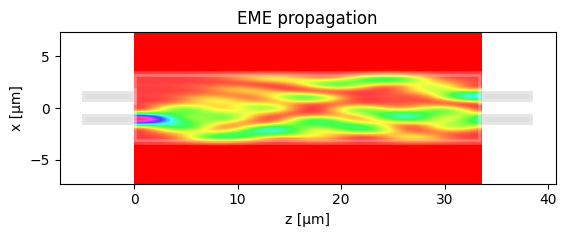

In [32]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi # STUDENT

# Run propagation
m.propagation()

### LO.4.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/670 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -1.0000
IO wg width 1.0000
IO wg width increment 0.1000
------------------------
Total power IN coupled 0.9568
Total OUT power: 0.8986
Excess loss [dB] =  0.4643
------------------------
Power over OUTs:  ['0.4449', '0.4537']
Ratio over OUTs ['0.4951', '0.5049']


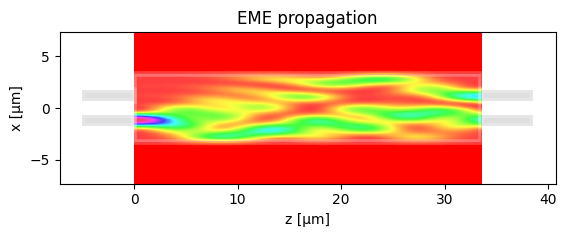

In [33]:
dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,+dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,+dy])

# MMI length (check class slides for type of MMI)
m.dL_MMI = -1 # STUDENT

# Run propagation
m.propagation()

### LO.4.3 2x2 Multimode Interference Coupler – Optimization (II)

In [30]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 0.1 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03590455329623  µm


/Applications/Desktop/DESIGN LAB MASTER/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


In [ ]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = ... # STUDENT
m.n_OUT = ... # STUDENT

dy = 0.0
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = ... # STUDENT
m.OUT_WVG_positions = ... # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = ...  # STUDENT
m.dL_MMI = ... # STUDENT

# Run propagation
m.propagation()

## LO.5. 1x4 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

## Extra - Exercises

### E1. Directional coupler gap dependence

In [ ]:
gap_to_simulate = 600 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=gap_to_simulate,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

# STUDENT. Plot goes here


### E2. Directional coupler wavelength dependence

In [ ]:
wavelength = ... # STUDENT code goes here

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=600 * nm,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

deep_neff = deep_dcoupler_cs.n_eff
L_pi_TE = ... # STUDENT code here

plt.figure(figsize=(10, 5))
plt.scatter(wavelength, L_pi_TE,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(wavelength, L_pi_TE,label='Deep')
plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

### E3. MMI coupler wavelength dependence

In [ ]:
mmi_body_w = 6.6 
lambda_c = ... # STUDENT code goes here.

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 

### E4. MMI coupler body width dependence

In [ ]:
lambda_c = 1.55

mmi_body_w = 6.6 # STUDENT. You can manually change the body width
                 # or you can sweep the parameter using a Python for loop. 

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 